In [10]:
"""
3. snntorch `beta`를 0.5/0.9/0.99로 바꿔 hidden 막전위 trace 시각화.
4. Day 6 LIF와 snntorch `Leaky`의 출력을 같은 입력·파라미터에서 비교 검증.
"""
# === 셀 1: 환경 변수 (반드시 import 전에) ===
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# === 셀 2: import ===
import snntorch as snn
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# === 셀 3: SNN 정의 ===
class SNN(nn.Module):
    def __init__(self, beta=0.95):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(8, 2)
        self.lif2 = snn.Leaky(beta=beta)
    
    def forward(self, x, n_steps=25):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk_rec, mem_rec = [], []
        for _ in range(n_steps):
            spk1, mem1 = self.lif1(self.fc1(x), mem1)
            spk2, mem2 = self.lif2(self.fc2(spk1), mem2)
            spk_rec.append(spk2)
            mem_rec.append(mem2)
        
        return torch.stack(spk_rec), torch.stack(mem_rec)

# === 셀 4: 실행 ===
torch.manual_seed(42)
net = SNN(beta=0.95)
x = torch.randn(1, 4)

spk_out, mem_out = net(x, n_steps=25)
print(f"Output shape: {spk_out.shape}")

class_spikes = spk_out.sum(dim=0).squeeze()
pred = class_spikes.argmax().item()
print(f"Class 0: {int(class_spikes[0])}, Class 1: {int(class_spikes[1])}")
print(f"Prediction: Class {pred}")

Output shape: torch.Size([25, 1, 2])
Class 0: 7, Class 1: 1
Prediction: Class 0


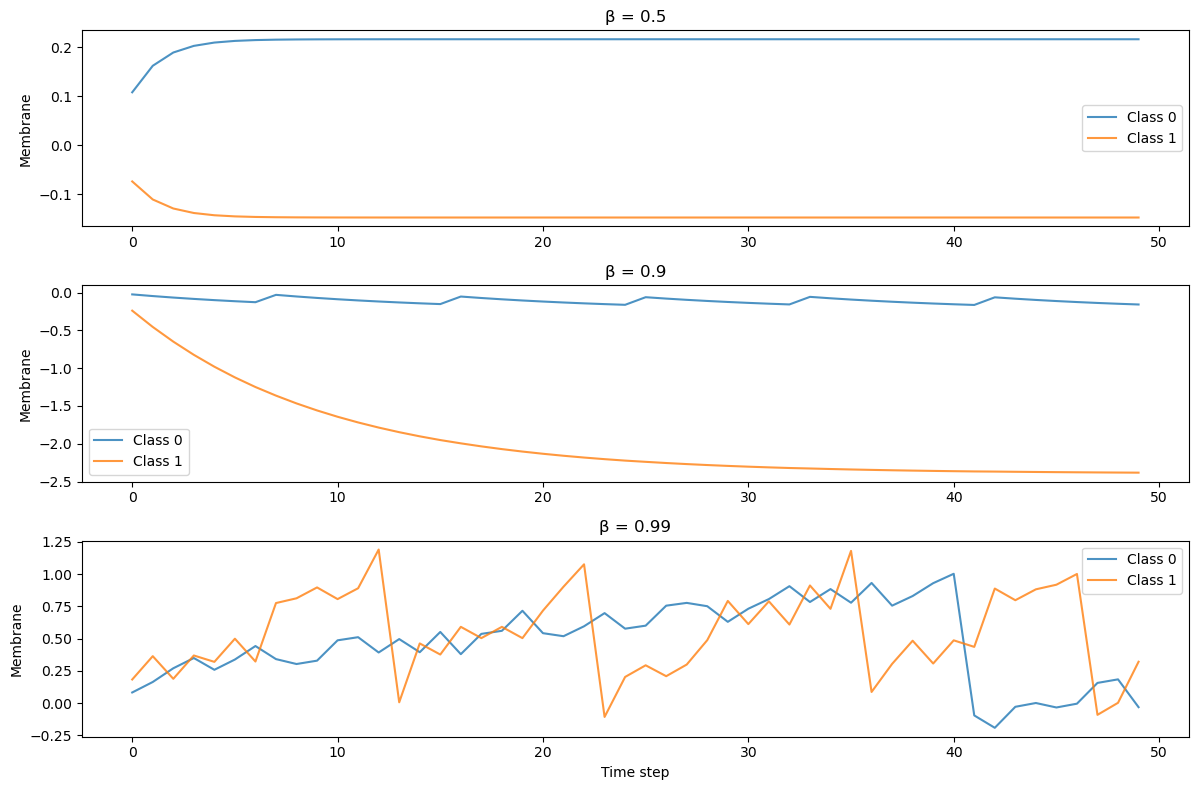

In [13]:
# 3. snntorch `beta`를 0.5/0.9/0.99로 바꿔 hidden 막전위 trace 시각화.

betas = [0.5, 0.9, 0.99]
fig, axes = plt.subplots(3,1,figsize=(12,8))

torch.manual_seed(42)
x = torch.randn(1, 4)

for idx, beta in enumerate(betas):
    net = SNN(beta=beta)

    spk_out, mem = net(x, n_steps=50)
    axes[idx].plot(mem[:, 0, 0].detach(), label='Class 0', alpha=0.8)
    axes[idx].plot(mem[:, 0, 1].detach(), label='Class 1', alpha=0.8)
    axes[idx].set_title(f"β = {beta}")
    axes[idx].set_ylabel("Membrane")
    axes[idx].legend()
    
axes[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

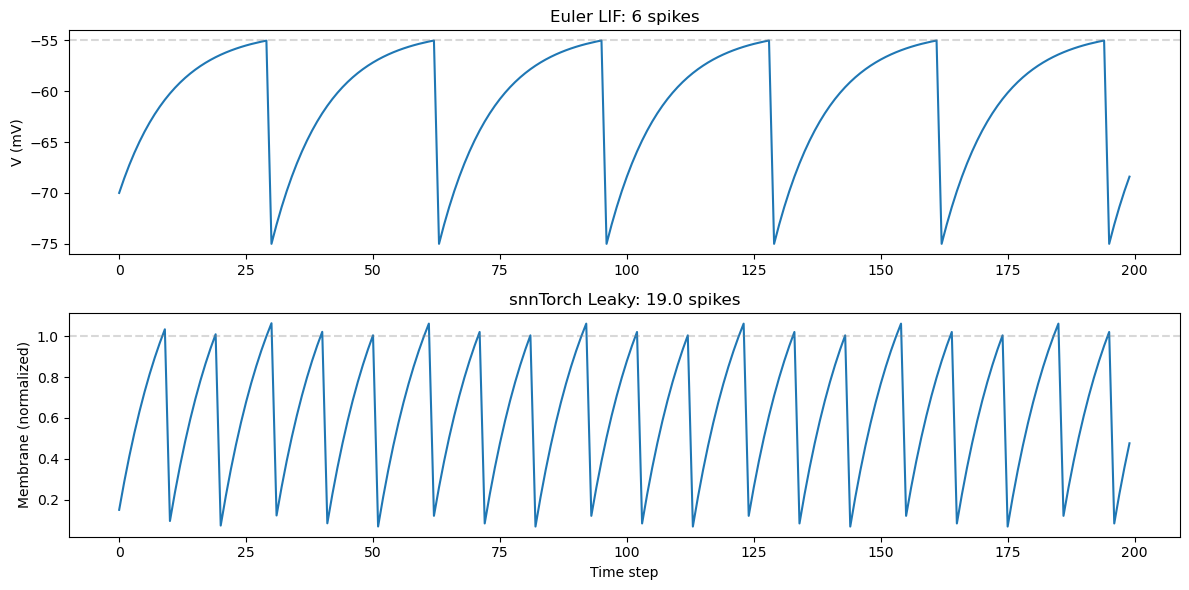

Euler spikes: 6
snnTorch spikes: 19.0


In [16]:
import numpy as np
import torch
import snntorch as snn

# === 공통 파라미터 ===
T = 200          # step
dt = 0.9         # 단순화 위해 dt=1
tau = 10.0       # ms
I_const = 1.6    # nA

# === 본인의 Euler LIF (단순화 버전) ===
def euler_lif(I, T, tau, dt, V_rest=-70, V_th=-55, V_reset=-75, R=10):
    V = np.zeros(T); V[0] = V_rest
    spikes = []
    for t in range(1, T):
        dV = (-(V[t-1] - V_rest) + R*I) / tau
        V[t] = V[t-1] + dV * dt
        if V[t] > V_th:
            spikes.append(t)
            V[t] = V_reset
    return V, spikes

V_euler, spikes_euler = euler_lif(I_const, T, tau, dt)

# === snnTorch (β = exp(-dt/tau)) ===
beta = np.exp(-dt/tau)
lif = snn.Leaky(beta=beta, threshold=1.0)

# 입력 스케일링: snn.Leaky는 정규화된 입력 기대
# R*I=16mV, threshold gap=15mV → 입력을 정규화
I_snn = torch.full((T, 1), 0.15)   # gap의 약 1/100 (parameter tuning 필요)

mem = lif.init_leaky()
mem_history, spike_history = [], []
for t in range(T):
    spk, mem = lif(I_snn[t], mem)
    mem_history.append(mem.item())
    spike_history.append(spk.item())

# === 비교 시각화 ===
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(V_euler, label='Euler LIF')
axes[0].axhline(-55, color='gray', linestyle='--', alpha=0.3)
axes[0].set_title(f"Euler LIF: {len(spikes_euler)} spikes")
axes[0].set_ylabel("V (mV)")

axes[1].plot(mem_history, label='snnTorch')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.3)
axes[1].set_title(f"snnTorch Leaky: {sum(spike_history)} spikes")
axes[1].set_ylabel("Membrane (normalized)")
axes[1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

print(f"Euler spikes: {len(spikes_euler)}")
print(f"snnTorch spikes: {sum(spike_history)}")